# 03 — Would a model trained through 2022 have seen Silicon Valley Bank coming?

Silicon Valley Bank (CERT 24735) failed on 10 March 2023, Signature Bank (57053) two days
later and First Republic Bank (59017) on 1 May 2023: the three largest failures since
2008, and none of them a credit story. Their loans were performing. What sank them was
the other side of the balance sheet: long-dated securities bought at 2020-2021 yields
that had lost a large share of their value after the 2022 rate rises, funded by deposits
that were mostly above the $250,000 insurance limit and could leave in an afternoon.

This notebook asks the question the project was built around: with strict point-in-time
discipline, would a model trained on everything known by the 2022Q4 prediction date have
ranked these three banks near the top? Two *views* are fitted with the same two learners:

- **credit-only**: the 43 Prototype 1 `features_v1` ratios (capital, asset quality,
  earnings, funding, concentrations, size);
- **rate-aware**: all 83 `features_v2` columns, which add unrealised securities losses
  relative to Tier 1 capital, the uninsured-deposit share, the trend and persistence
  blocks and the macro rates.

The learners are the Prototype 1 regularised logit (`LOGIT_C`, chosen on a validation
slice inside 2002-2008) and the tuned gradient booster (`settings.models.gbdt`). Nothing
is re-tuned on 2022-2023 data.

## 1. Training rows: windows closed before 1 March 2023

The prediction date of a 2022Q4 report is 2023-03-01 (report date plus the 60-day
availability lag). Rule 6.2 keeps a training row only if its 4-quarter outcome window
had already closed on that date, which `bankcanary.splits.training_mask` enforces and
`assert_no_leakage` re-checks on the selected rows: the last usable report is 2021Q3.
The fitted models then score the 2022Q3, 2022Q4 and 2023Q1 reports of every bank.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd() if (Path.cwd() / "config" / "settings.yaml").exists() else Path.cwd().parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from bankcanary.config import load_settings
from bankcanary.evaluation import case_study_2023 as cs

settings = load_settings()
pd.set_option("display.width", 140)
plt.rcParams["figure.dpi"] = 100
frame = cs.load_frame(settings)
train = cs.training_rows(frame, settings)
scored = cs.scoring_rows(frame)
print(f"{len(frame):,} bank-quarters in features_v2")
tr = frame.loc[train, "repdte"]
print(f"training rows: {int(train.sum()):,} ({int(frame.loc[train, 'y_4q'].sum()):,} failures), "
      f"reports {tr.min():%Y-%m-%d} to {tr.max():%Y-%m-%d}")
quarters = sorted(frame.loc[scored, "repdte"].dt.strftime("%Y-%m-%d").unique())
print(f"scored rows: {int(scored.sum()):,} over {quarters}")
frame.loc[frame["cert"].isin(cs.BANKS) & scored, ["cert", "repdte", "name", "asset", "fail_date"]]

710,691 bank-quarters in features_v2
training rows: 622,341 (2,226 failures), reports 2001-03-31 to 2021-09-30
scored rows: 14,326 over ['2022-09-30', '2022-12-31', '2023-03-31']


,cert,repdte,name,asset,fail_date
452765,24735,2022-09-30,SILICON VALLEY BANK,210244000.0,2023-03-10
452766,24735,2022-12-31,SILICON VALLEY BANK,209026000.0,2023-03-10
641214,57053,2022-09-30,SIGNATURE BANK,114468746.0,2023-03-12
641215,57053,2022-12-31,SIGNATURE BANK,110363650.0,2023-03-12
702628,59017,2022-09-30,FIRST REPUBLIC BANK,205108685.0,2023-05-01
702629,59017,2022-12-31,FIRST REPUBLIC BANK,212638872.0,2023-05-01
702630,59017,2023-03-31,FIRST REPUBLIC BANK,232944161.0,2023-05-01


## 2. Four fits, three banks, three quarters

`run_case_study` fits `logit` and `gbdt` on each view (about 30 seconds in total, no
subsampling needed) and ranks every scored bank within its quarter: rank 1 is the
riskiest bank, the percentile is the share of scored banks ranked below it. Each fit is
logged as a run record under `runs/case_study_2023/` with the split facts and the three
banks' ranks. SVB and Signature failed before filing a 2023Q1 report, so they have no
row in that quarter; First Republic's 2023Q1 report is scored although it was published
after the bank failed (it is the post-failure report the labels exclude from training).

In [2]:
study = cs.run_case_study(frame, settings)
report = cs.write_report(study, settings)
print("report:", report)
ranks = study.table.pivot_table(
    index=["bank", "quarter"], columns=["view", "model"], values="rank"
).astype("Int64")
ranks

report: /Users/batuhanisik/Desktop/Projects/bank-failure-early-warning/reports/svb_2023_case_study.md


view                        credit_only       rate_aware      
model                              gbdt logit       gbdt logit
bank                quarter                                   
First Republic Bank 2022Q3         1423  1760       1889  2698
                    2022Q4         1167  1570       1416  1750
                    2023Q1          904   308       1299   225
Signature Bank      2022Q3         2515   172       1768  1031
                    2022Q4         1648   113       2634   627
Silicon Valley Bank 2022Q3         1577  2336        274  3315
                    2022Q4         1412  1677        245  1854

In [3]:
pct = study.table.pivot_table(
    index=["bank", "quarter"], columns=["view", "model"], values="percentile"
).round(1)
prob = study.table.pivot_table(
    index=["bank", "quarter"], columns=["view", "model"], values="probability"
)
print("Percentile (100 = riskiest bank of the quarter)")
display(pct)
print("Probability of failure within four quarters")
prob.map(lambda v: f"{v:.5f}" if pd.notna(v) else "")

Percentile (100 = riskiest bank of the quarter)


view                        credit_only       rate_aware      
model                              gbdt logit       gbdt logit
bank                quarter                                   
First Republic Bank 2022Q3         70.4  63.4       60.8  43.9
                    2022Q4         75.5  67.1       70.3  63.3
                    2023Q1         80.9  93.5       72.6  95.3
Signature Bank      2022Q3         47.7  96.4       63.3  78.6
                    2022Q4         65.5  97.6       44.8  86.9
Silicon Valley Bank 2022Q3         67.2  51.5       94.3  31.1
                    2022Q4         70.4  64.9       94.9  61.2

Probability of failure within four quarters


view                        credit_only          rate_aware         
model                              gbdt    logit       gbdt    logit
bank                quarter                                         
First Republic Bank 2022Q3      0.00006  0.00028    0.00006  0.00011
                    2022Q4      0.00006  0.00031    0.00007  0.00024
                    2023Q1      0.00007  0.00086    0.00005  0.00077
Signature Bank      2022Q3      0.00004  0.00106    0.00006  0.00023
                    2022Q4      0.00005  0.00140    0.00004  0.00046
Silicon Valley Bank 2022Q3      0.00005  0.00022    0.00029  0.00008
                    2022Q4      0.00006  0.00030    0.00029  0.00023

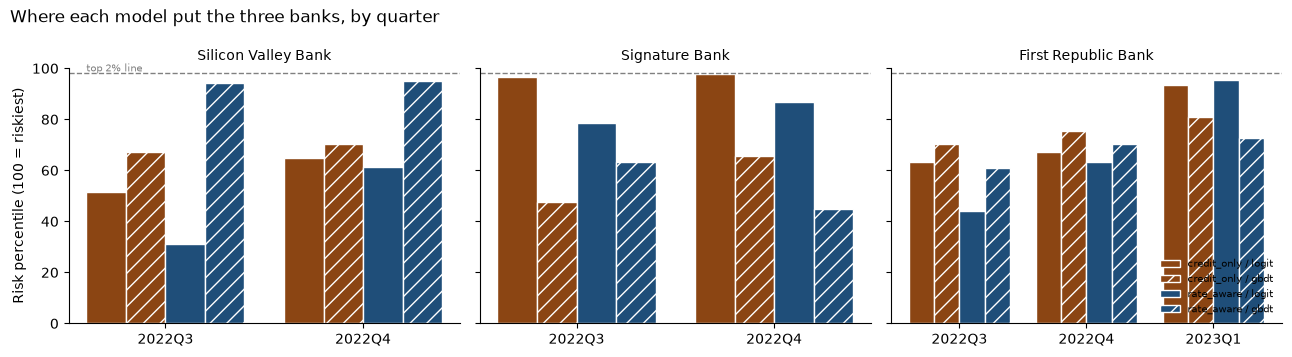

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
order = [(view, model) for view in cs.VIEWS for model in cs.MODELS]
colors = {"credit_only": "#8B4513", "rate_aware": "#1f4e79"}
hatch = {"logit": "", "gbdt": "//"}
for ax, (cert, name) in zip(axes, cs.BANKS.items()):
    sub = study.table.loc[study.table["cert"].eq(cert)]
    quarters = sorted(sub["quarter"].unique())
    width = 0.8 / len(order)
    for i, (view, model) in enumerate(order):
        cell = sub.loc[sub["view"].eq(view) & sub["model"].eq(model)].set_index("quarter")
        x = np.arange(len(quarters)) + (i - 1.5) * width
        ax.bar(x, cell["percentile"].reindex(quarters).to_numpy(), width,
               color=colors[view], hatch=hatch[model], edgecolor="white", label=f"{view} / {model}")
    ax.axhline(98, color="grey", linestyle="--", linewidth=1)
    ax.set_xticks(np.arange(len(quarters)), quarters)
    ax.set_title(name, fontsize=10)
    ax.set_ylim(0, 100)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("Risk percentile (100 = riskiest)")
axes[0].text(-0.4, 98.8, "top 2% line", fontsize=7, color="grey")
axes[-1].legend(fontsize=7, frameon=False, loc="lower right")
fig.suptitle("Where each model put the three banks, by quarter", x=0.01, ha="left")
plt.tight_layout()
plt.show()

## 3. What drove SVB's 2022Q4 score under each model

For the boosters the contributions are SHAP values from the tree explainer on the
winsorised inputs; for the logits they are coefficient times standardised value on the
pipeline's own winsorise-impute-scale output. Both sum to the bank's log-odds minus the
model's baseline (the expected log-odds for the booster, the intercept for the logit),
so positive bars push SVB towards failure and negative bars away from it.

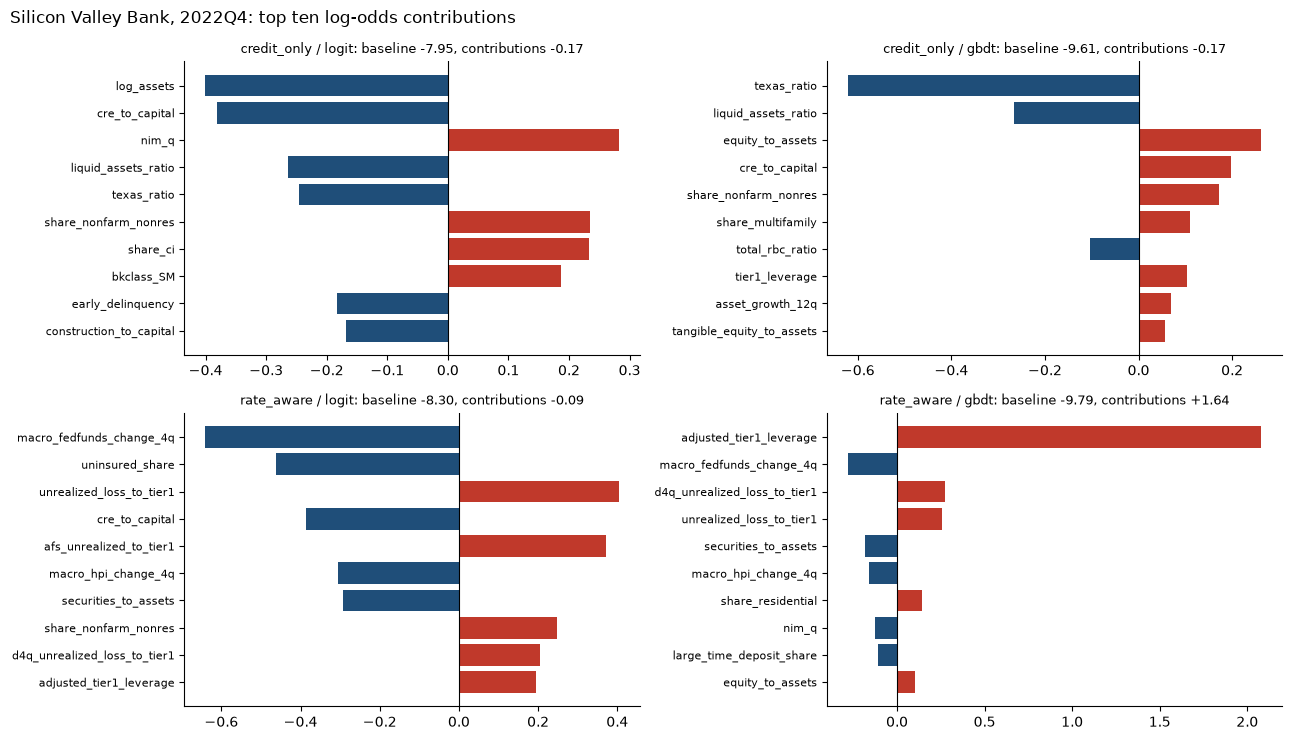

,feature,value,contribution,direction
0,adjusted_tier1_leverage,-0.330102,2.0801,riskier
1,macro_fedfunds_change_4q,4.49,-0.2821,safer
2,d4q_unrealized_loss_to_tier1,-0.963866,0.2766,riskier
3,unrealized_loss_to_tier1,-1.0406,0.2583,riskier
4,securities_to_assets,0.56116,-0.1851,safer
5,macro_hpi_change_4q,0.131153,-0.1592,safer
6,share_residential,0.122588,0.1397,riskier
7,nim_q,0.021038,-0.1258,safer
8,large_time_deposit_share,0.008006,-0.1111,safer
9,equity_to_assets,0.073943,0.1000,riskier


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))
for ax, ((view, model), table) in zip(axes.ravel(), study.drivers.items()):
    top = table.iloc[::-1]
    color = np.where(top["contribution"] > 0, "#c0392b", "#1f4e79")
    ax.barh(top["feature"], top["contribution"], color=color)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(
        f"{view} / {model}: baseline {table.attrs['baseline']:.2f}, "
        f"contributions {table.attrs['total']:+.2f}",
        fontsize=9,
    )
    ax.tick_params(axis="y", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Silicon Valley Bank, 2022Q4: top ten log-odds contributions", x=0.01, ha="left")
plt.tight_layout()
plt.show()
study.drivers[("rate_aware", "gbdt")].round(4)

In [6]:
study.drivers[("rate_aware", "logit")].round(4)

,feature,value,contribution,direction
0,macro_fedfunds_change_4q,4.49,-0.6408,safer
1,uninsured_share,0.864373,-0.4610,safer
2,unrealized_loss_to_tier1,-1.0406,0.4038,riskier
3,cre_to_capital,0.133848,-0.3874,safer
4,afs_unrealized_to_tier1,-0.148632,0.3725,riskier
5,macro_hpi_change_4q,0.131153,-0.3063,safer
6,securities_to_assets,0.56116,-0.2936,safer
7,share_nonfarm_nonres,0.023529,0.2473,riskier
8,d4q_unrealized_loss_to_tier1,-0.963866,0.2050,riskier
9,adjusted_tier1_leverage,-0.330102,0.1957,riskier


## 4. Unrealised losses and uninsured deposits against the large-bank peer group

`unrealized_loss_to_tier1` is the sum of unrealised gains and losses on
available-for-sale and held-to-maturity securities divided by Tier 1 capital (negative
means losses); `uninsured_share` is the share of deposits above the insurance limit. The
band is the 5th-95th percentile of every bank with more than $10 billion of assets,
2020Q1-2023Q1, and the line is its median.

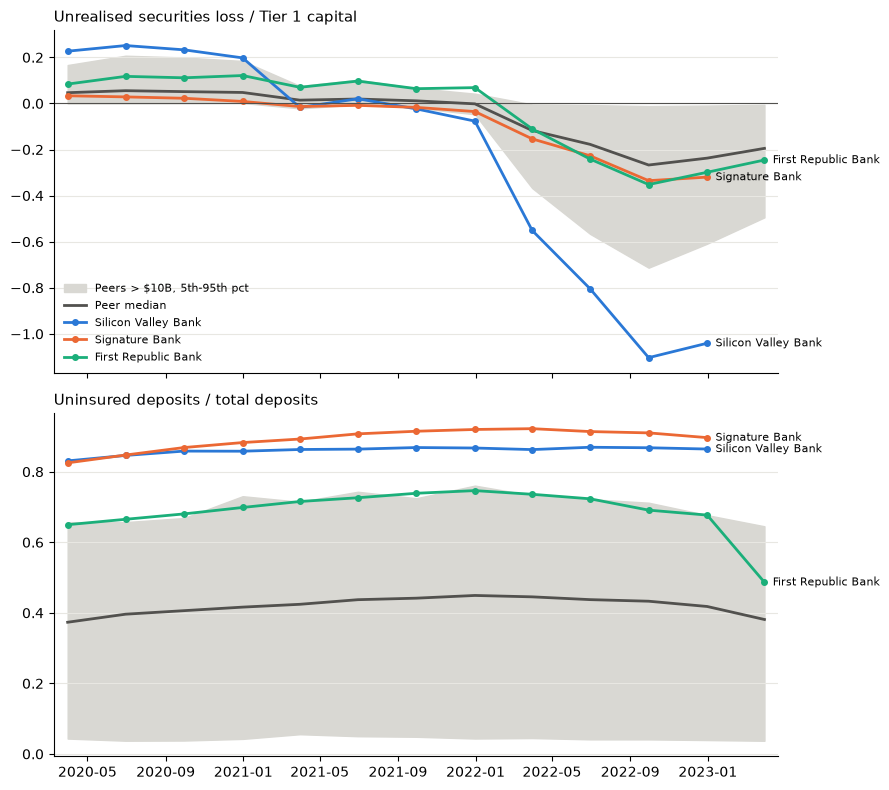

SVB 2022Q4: unrealized_loss_to_tier1 -1.0406, uninsured_share 0.8644, adjusted_tier1_leverage -0.3301, texas_ratio 0.0088, noncurrent_ratio 0.0019, equity_to_assets 0.0739, liquid_assets_ratio 0.6244


In [7]:
COLORS = {24735: "#2a78d6", 57053: "#eb6834", 59017: "#1baf7a"}
fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)
for ax, (col, title) in zip(axes, cs.CHART_FEATURES.items()):
    band = cs.peer_bands(frame, col)
    ax.fill_between(band.index, band[0.05], band[0.95], color="#d9d8d3",
                    label="Peers > $10B, 5th-95th pct")
    ax.plot(band.index, band[0.5], color="#52514e", lw=2, label="Peer median")
    for cert, name in cs.BANKS.items():
        rows = frame.loc[frame["cert"].eq(cert) & frame["repdte"].between(*cs.CHART_WINDOW)]
        s = rows.set_index("repdte")[col].dropna()
        ax.plot(s.index, s.to_numpy(), color=COLORS[cert], lw=2, marker="o", ms=4, label=name)
        ax.annotate(name, (s.index[-1], s.iloc[-1]), xytext=(6, 0),
                    textcoords="offset points", fontsize=8, va="center")
    ax.set_title(title, loc="left", fontsize=11)
    ax.grid(axis="y", color="#e8e7e2", lw=0.8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.margins(x=0.02)
axes[0].axhline(0, color="#52514e", lw=0.8)
axes[0].legend(loc="lower left", fontsize=8, frameon=False)
plt.tight_layout()
plt.show()
svb = frame.loc[frame["cert"].eq(24735) & frame["repdte"].eq("2022-12-31")].iloc[0]
keys = ["unrealized_loss_to_tier1", "uninsured_share", "adjusted_tier1_leverage",
        "texas_ratio", "noncurrent_ratio", "equity_to_assets", "liquid_assets_ratio"]
print("SVB 2022Q4:", ", ".join(f"{k} {svb[k]:.4f}" for k in keys))

## 5. Why the credit-only view misses them, and what the rate-aware view adds

**The credit ratios looked fine.** At 2022Q4 SVB's Texas ratio was 0.009 and its
noncurrent ratio a few tenths of a percent, both well inside the healthy range, its
equity-to-assets 7.4 percent and its liquid-assets ratio 0.62. Every large credit-only
driver pushes it *towards* safety (`texas_ratio`, `liquid_assets_ratio`, `log_assets`);
the small positive contributions come from nonfarm-nonresidential and multifamily loan
shares. The credit-only models place it at the 65th-70th percentile: an ordinary bank.
First Republic reads the same way (67th-76th). Signature is the one exception, and for
a reason that has nothing to do with 2023: the credit-only logit ranks it 113th of
4,773 (97.6th percentile) on its C&I loan share, CRE at three times capital and its
multifamily book, which is the 2008-style concentration profile the model was trained
to fear. The booster does not share that view (65th percentile).

**What the rate-aware view adds, and where it falls short.** The `features_v2` columns
show what the credit ratios cannot: SVB's unrealised securities losses reached 104
percent of Tier 1 capital by 2022Q4 (`unrealized_loss_to_tier1` = -1.04, against a
median of -0.24 and a 5th percentile of -0.61 among banks above $10 billion), its
capital net of those losses was negative (`adjusted_tier1_leverage` = -0.33, where the
same peers sat between 2.9 and 11.1) and 86 percent of its deposits were uninsured. The
rate-aware booster reacts to exactly that: `adjusted_tier1_leverage` alone contributes
+2.1 to SVB's log-odds, the unrealised-loss level and its four-quarter change add another
+0.5, and SVB moves from rank 1,412 to rank 245 of 4,773 (94.9th percentile, fourth of
the 34 banks above $100 billion). In the training years, negative capital net of
securities losses was rare (116 bank-quarters) and 55 of those banks failed, so the trees
learned it as a decisive split. The logit cannot: its coefficients are averages over
2001-2021, when a high uninsured share marked large, well-run banks (failed banks
averaged 13 percent uninsured deposits, survivors 20 percent) and rising policy rates
marked calm years, so `uninsured_share` and `macro_fedfunds_change_4q` enter with
*safer* signs and offset the loss terms; the rate-aware logit leaves SVB at the 61st
percentile. Signature and First Republic gain nothing from the new columns under either
learner: their unrealised securities losses (-0.32 and -0.30 of Tier 1) sat inside the
large-bank band (First Republic's problem was the fair value of its long fixed-rate
mortgages, which the Call Report does not mark), their adjusted leverage stayed positive
(6.2 and 5.8), and their uninsured shares (90 and 68 percent), while at or above the
peer 95th percentile, carried no risk signal in the training years for the reason above.
The honest summary is that the rate-aware features
let the booster flag SVB as a top-5 percent bank two quarters before it failed, on the
mechanism that actually failed it, and that the deposit-run side of the story is
something no model trained on 2001-2021 outcomes could have learned.

## 6. Caveats

- **Three banks.** This is a case study, not an evaluation: three events, chosen because
  they failed. The ranking metrics over the 14,326 scored reports (13 complete-label
  failures) are printed in the report for context only.
- **In-sample by construction.** The models were fit through the 2022Q4 prediction date
  and never see the 2023 outcomes, so the scores are point-in-time; but the cut, the
  three banks and the features to look at were chosen knowing what happened. The
  walk-forward backtest of notebook 02 is the out-of-sample evidence.
- **The hyper-parameters are the 2002-2008 ones.** `LOGIT_C` and the booster settings
  were tuned on the P1 fixed split (rule 6.7) and reused unchanged; the unconstrained
  booster (`settings.models.gbdt.monotone = false`) is the one shown. The registry's
  `+1` sign on `uninsured_share` would force the monotone config to read it as risk.
- **Probabilities stay small.** Even SVB's rate-aware booster score is 0.0003: the
  models rank, they do not sound an alarm, and the value of the case study is the rank.
- **The labels' 2023Q1 gap.** SVB and Signature never filed a 2023Q1 report; First
  Republic's is a post-failure filing and is scored but was never in any training set.